# Homework 5: *Numerical estimations of the Quantum Harmonic Oscilator*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import prange, njit
from numba.typed import List

In [2]:
np.random.seed(42) # <---

## Section A

In this section, we consider **a particle in a harmonic potential** $$V(x) = \frac{1}{2}x^2$$ at very low temperatures ($T \to 0$).

### A1: Classical

The probability of a **classical particle**, at temperature $T$, to be at position $x$ is $$\pi(x) \propto \exp{\Big( -\beta\frac{x^2}{2}\Big)}$$
where $\displaystyle\beta = \frac{1}{k_B\, T}$.

- Because in essence $\pi(x)$ is normally distributed with standard deviation $\sigma \propto \sqrt{T}$, as temperature goes to zero the mass of the distribution is localized at $x=0$.

### A1 (continued)

The ground-state wave function of a quantum particle in a harmonic trap is equal to $$\psi_0(x) = \frac{1}{\pi^{1/4}} \exp{( - x^2 / 2)}$$

In the limit $T\to 0$, the probability $\pi(x)$ of a quantum particle to be at $x$ is equal to the square of the ground state wave function, $\psi_0(x)^2$.

Familiarize yourself with the Markov-chain Monte Carlo algorithm for a particle in a Gaussian potential, using the Metropolis algorithm:  namely the program `markov_gauss.py` (this program was discussed in last week's Tutorial, Tutorial 4). 

Modify this Metropolis algorithm so that it  samples positions $x$ according to the probability $$\pi(x) \propto \psi_0(x)^2$$

You should use a function for the square of the wave function (`def psi_0_sq(x): ...`). 

Furthermore, the program should output the **normed histogram** of the particle positions (use `plt.hist()` with `normed=True`) and compare to the function `psi_0^2(x)`.

```python
# markov_gauss.py
import random, math

x = 0.0
xs = [x]
delta = 0.5
for k in range(100000):
    x_new = x + random.uniform(-delta, delta)
    if random.uniform(0.0, 1.0) < math.exp (- x_new ** 2 / 2.0) / math.exp (- x ** 2 / 2.0): 
        x = x_new 
    xs.append(x)
```

The distribution therefore is $$\pi(x) \propto \frac{1}{\sqrt{\pi}} \exp{\Big(- x^2\Big)}$$

For standard deviation $\sigma$ it must hold $2\sigma^2 = 1$, therefore $$\sigma = \frac{1}{\sqrt{2}}$$

In [3]:
@njit
def psi_0_sq(x):
    return (1 / np.sqrt(np.pi)) * np.exp(-x * x)

In [4]:
@njit
def metropolis_psi_0_sq(x_init: float = 0.0,
                        delta: float = 0.1,
                        n_steps: int = 100_000) -> np.ndarray:
    '''Samples from the distribution `psi_0_sq`.'''
    samples = np.full(n_steps, x_init)
    for i in range(1, n_steps):
        x = samples[i-1]
        dx = np.random.uniform(-delta, delta)
        if np.random.uniform(0, 1) < psi_0_sq(x + dx) / psi_0_sq(x):
            x += dx
        samples[i] = x
    return samples

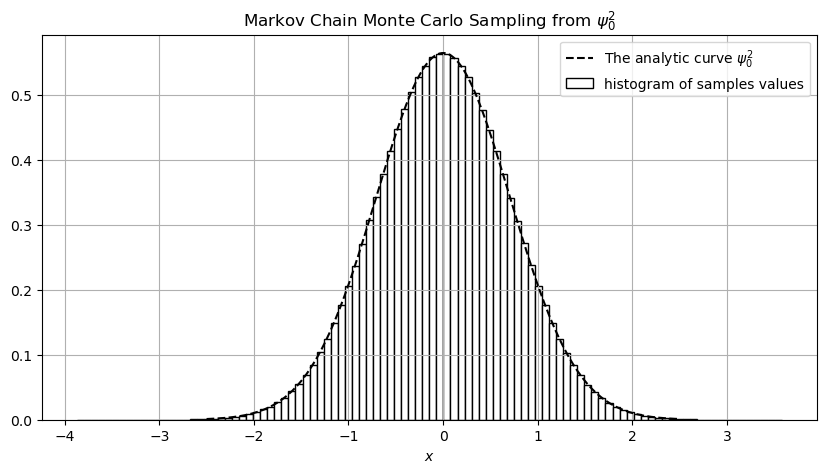

In [5]:
xs = metropolis_psi_0_sq(delta=0.5, n_steps=10_000_000)
xrange = np.linspace(-2.5, 2.5, 200)
plt.figure(figsize=(10,5))
plt.plot(xrange, psi_0_sq(xrange),
         '--', color='black',
        label=r"The analytic curve $\psi_0^2$")
plt.hist(xs, bins=100, density=True,
         color='white', edgecolor='black',
         label='histogram of samples values')
plt.grid()
plt.xlabel(r"$x$")
plt.title(r"Markov Chain Monte Carlo Sampling from $\psi_0^2$")
plt.legend()
plt.savefig("plots/psi_0_sq_hist.png")
plt.show()

### A2: Quantum
In this Section, you consider the **quantum particle in the harmonic potential**, at finite temperature. 

Its probability to be in state n and at position x is given by $$\pi(n, x)  =  \psi^2_n(x) \; \exp{(-\beta  E_n)}$$

Here, the energies $E_n = n + \frac{1}{2}$, and the wave functions $\psi_n(x)$ are known through the **recursion** discussed in `harmonic_wavefunction.py` (as discussed in lecture 5). You do not need to understand why this recursion is correct, but you can check that this is ok in `harmonic_wavefunction_check.py` (see Lecture 5).

The probability $\pi(n, x)$ expresses two fundamental aspects:

- The particle is in state $n$ with the statistical Boltzmann probability proportional to $\exp{(-\beta\;  n)}$  (because $E_n = n + 1/2$, and because the integral of $\psi^2_n(x)$ is equal to one).

- While in state $n$, the particle is at position $x$ with the quantum probability $\psi^2_n(x)$.

Modify your program from Section A1 to simulate the particle at finite temperature $T = 1/\beta$. 

To do so, modify the program from Section *A1*, in order to accept the move  from $(n, x)$ to $(n, x^\prime)$  with the Metropolis acceptance rate $$\min\Big\{1, \Big(\frac{\psi_n(x')}{\psi_n(x)}\Big)^2\Big\}$$ ($x^\prime$ should be close to x, as in Section A1).  Modify the program further, and add a move which keeps $x$ fixed and changes $n$ to $m = n \pm 1$. Such a move from $(n, x)$ to $(n \pm 1, x)$ should be accepted with the
$$p = \min\Big\{1,\;\; \Big[\frac{\psi_m(x)}{\psi_n(x)}\Big]^2  \exp{\big(-\beta(E_m-E_n)\big)}\Big\}$$ 

Moves to $m < 0$ must be proposed (piles of pebbles!!), but they should always be rejected.


In writing this program, you may alternate the moves (attempt $(n, x)$ to $(n, x')$ then attempt $(n, x)$ to $(n \pm 1, x)$ etc). Furthermore, use the following rewriting of the recursion for the harmonic wave functions (from `harmonic_wavefunction.py` see lecture 5), which returns $\psi^2_n(x)$, and do not worry about the fact that it is slow:


```python
def psi_n_square(x, n):
    if n == -1:
        return 0.0
    else:
        psi = [math.exp(-x ** 2 / 2.0) / math.pi ** 0.25]
        psi.append(math.sqrt(2.0) * x * psi[0])
        for k in range(2, n + 1):
            psi.append(math.sqrt(2.0 / k) * x * psi[k - 1] -
                       math.sqrt((k - 1.0) / k) * psi[k - 2])
        return psi[n] ** 2
```

In [6]:
# Numba optimized
@njit
def psi_n_square(x, n):
    
    if n == -1:
        return 0.0
        
    # base cases
    psi_nm2 = np.exp(-x * x / 2.0) / np.pi ** 0.25  # psi[0]
    if n == 0: 
        return psi_nm2 * psi_nm2

    psi_nm1 = np.sqrt(2.0) * x * psi_nm2  # psi[1]
    if n == 1:
        return psi_nm1 * psi_nm1

    # recurrence
    for k in range(2, n + 1):
        psi_n_val = (np.sqrt(2.0 / k) * x * psi_nm1 -
                     np.sqrt((k - 1.0) / k) * psi_nm2)
        psi_nm2 = psi_nm1
        psi_nm1 = psi_n_val

    return psi_nm1 * psi_nm1

In [7]:
@njit
def metropolis_psi_n_sq(state: tuple[float, int] = (0.0, 0),
                        beta: float = 0.04,
                        delta: float = 0.05,
                        n_steps: int = 1_000_000) -> tuple[np.ndarray, np.ndarray]:
    '''Samples from the distribution `psi_n_sq`.'''
    
    x, n = state
    xs = np.full(n_steps, x)
    ns = np.full(n_steps, n, dtype=np.uint32)
    
    for i in range(1, n_steps):
        x, n = xs[i-1], ns[i-1]
        dx = np.random.uniform(-delta, delta)
        p1 = np.minimum(1, psi_n_square(x + dx, n) / psi_n_square(x, n))
        if np.random.rand() < p1:
            x += dx
        m = n + np.random.choice(np.array([-1, 1], dtype=np.int8))
        En, Em = n + 0.5, m + 0.5
        p2 = np.minimum(1, 
                        psi_n_square(x, m) * np.exp(-beta * (Em - En)) / psi_n_square(x, n))
        if np.random.rand() < p2:
            n = m
        xs[i] = x
        ns[i] = n
    return xs, ns

### A2 (continued)

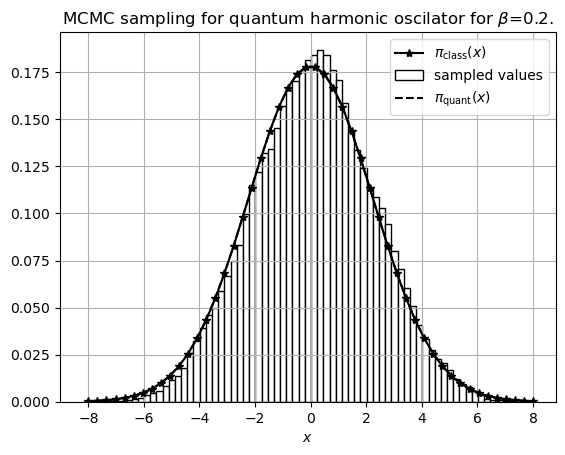

In [8]:
# Plot the histograms
beta = 0.2
xs_quant, _ = metropolis_psi_n_sq(beta=beta, n_steps=10_000_000)
xrange = np.linspace(-8, 8)
pi_class = np.sqrt(0.5 * beta / np.pi) * np.exp(- 0.5 * beta * xrange * xrange)
pi_quant = np.sqrt( np.tanh(beta/2) / np.pi) * np.exp( - np.square(xrange) * np.tanh(beta/2) )
plt.plot(xrange, pi_class, '-*', color='black', label=r'$\pi_\text{class}(x)$')
plt.hist(xs_quant, density=True, color='white', edgecolor='black', bins=70, label="sampled values")
plt.plot(xrange, pi_quant, '--', color='black', label=r"$\pi_\text{quant}(x)$")
plt.legend()
plt.xlabel(r"$x$")
plt.title(rf"MCMC sampling for quantum harmonic oscilator for $\beta$={beta}.")
plt.grid()
plt.savefig(f'plots/psi_n_sq_hists_beta_{beta:0.2f}.png')
plt.show()

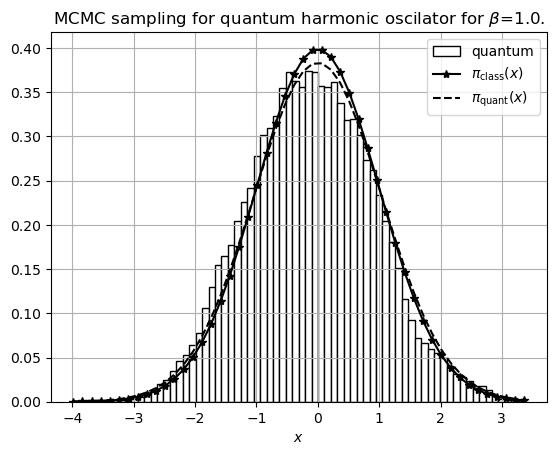

In [9]:
# Plot the histograms
beta = 1.0
xs_quant, _ = metropolis_psi_n_sq(beta=beta)
xrange = np.linspace(min(xs_quant), max(xs_quant))
pi_class = np.sqrt(0.5 * beta / np.pi) * np.exp(- 0.5 * beta * xrange * xrange)

pi_quant = np.sqrt( np.tanh(beta/2) / np.pi) * np.exp( - np.square(xrange) * np.tanh(beta/2) )
plt.hist(xs_quant, density=True, color='white', edgecolor='black', bins=70, label="quantum")
plt.plot(xrange, pi_class, '-*', color='black', label=r'$\pi_\text{class}(x)$')
plt.plot(xrange, pi_quant, '--', color='black', label=r"$\pi_\text{quant}(x)$")
plt.legend()
plt.xlabel(r"$x$")
plt.title(rf"MCMC sampling for quantum harmonic oscilator for $\beta$={beta}.")
plt.grid()
plt.savefig(f'plots/psi_n_sq_hists_beta_{beta:0.2f}.png')
plt.show()

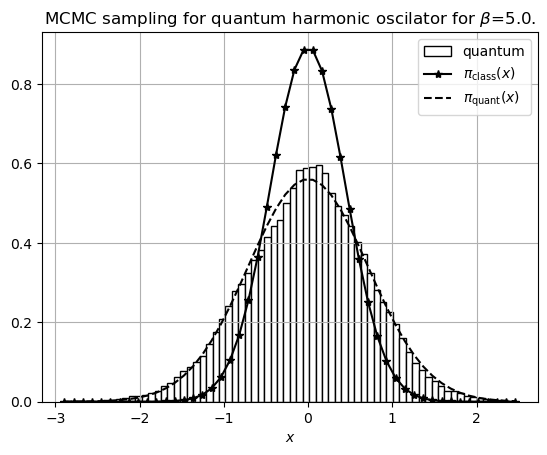

In [10]:
# Plot the histograms
beta = 5.0
xs_quant, _ = metropolis_psi_n_sq(beta=beta)
xrange = np.linspace(min(xs_quant), max(xs_quant))
pi_class = np.sqrt(0.5 * beta / np.pi) * np.exp(- 0.5 * beta * xrange * xrange)
pi_quant = np.sqrt( np.tanh(beta/2) / np.pi) * np.exp( - np.square(xrange) * np.tanh(beta/2) )

plt.hist(xs_quant, density=True, color='white', edgecolor='black', bins=70, label="quantum")
plt.plot(xrange, pi_class, '-*', color='black', label=r'$\pi_\text{class}(x)$')
plt.plot(xrange, pi_quant, '--', color='black', label=r"$\pi_\text{quant}(x)$")
plt.legend()
plt.xlabel(r"$x$")
plt.title(rf"MCMC sampling for quantum harmonic oscilator for $\beta$={beta}.")
plt.grid()
plt.savefig(f'plots/psi_n_sq_hists_beta_{beta:0.2f}.png')
plt.show()

### A2 (continued)


For all three values of $\beta = 0.2, 1, 5$ the sampled values (histogram) match the theoretical distribution very well. We observe that as $\beta$ increases (temperature decreases), the variance of the distribution decreases. Moreover, for large $\beta$ — i.e., at low temperatures — the quantum harmonic oscillator coincides exactly with the classical one. This can be seen from the theoretical distribution $$\pi_\text{quant}(x) = \sqrt{\frac{\tanh({\beta/2})}{\pi}} \exp{\Big(-x^2 \tanh({\beta/2})}\Big)$$

In the limit $\beta \to \infty$ the values of $\tanh({\beta/2})$ goes to $1$ and the distribution becomes $$\pi(x) = \sqrt{\frac{1}{\pi}} \exp{\Big(-x^2 \Big)}$$


## Section B

In Section **A2**, we were able to determine the probability $\pi(x)$ of the quantum particle to be at position $x$, because we had as input all the wave functions and all the energies.

In this Section, you will arrive at the same result (computation of $\pi(x)$) but without using this input. We will do **matrix-squaring** (Section B1) and **path-integral** Monte Carlo simulation (Section B2).

### B1: *Matrix Squaring*

- Download  the program `harmonic_matrix_square.py` (from Lecture 5).

- Modify your program further so that it outputs $\pi(x)$ at the final $\beta$ onto a file (notice that $\pi(x) = \frac{\rho(x, x, \beta)}{Z}$, with $Z = \int \rho(x,x,\beta) dx)$. This can be done by adding the following snippet
```python
Z = sum(rho[j, j] for j in range(nx + 1)) * dx
pi_of_x = [rho[j, j] / Z for j in range(nx + 1)]
f = open('data_harm_matrixsquaring_beta' + str(beta) + '.dat', 'w')
for j in range(nx + 1):
    f.write(str(x[j]) + ' ' + str(rho[j, j] / Z) + '\n')
f.close()
```

- Modify it so that it plots the $\pi(x)$ at the final $\beta$. In the same plot, show the analytic curve for $\pi(x)$ (the function `pi_quant(x)`, from section A2).

The **free density matrix** is $$\rho^\text{free}(x, x ^{\prime};\, \beta) = \frac{1}{\sqrt{2\pi \beta}}\exp{\Big(-\frac{(x - x^\prime)^2}{2\beta}\Big)}$$

At high temperatures - i.e. small $\beta$ - the  density matrix will approach the Dirac delta function 
$$\rho^\text{free}(x,x^\prime;\;\beta) \to \delta(x-x^\prime)$$

Applying the **Trotter** formula the density matrix (for low $\beta$) reduces to $$\rho(x, x^\prime; \beta) = \exp{(-\beta V(x))}$$ The classical Boltzmann distribution.

#### Free Density Matrix
The free density matrix is defined as $$\rho^\text{free}(x, x^\prime; \beta) = \frac{1}{2\sqrt{\pi \beta}} \exp{\big( -\frac{x^2}{2\beta}\big)}$$

In [1]:
def free_density_matrix(x: np.ndarray,
                        beta: float
                       ) -> np.ndarray:
    '''Computes the free density matrix'''
    X = x[:,None] - x[None, :]
    rho_free = (1 / np.sqrt(2 * np.pi * beta)) * np.exp(-np.square(X) / (2 * beta))
    return rho_free

#### Partition function
For a given $\beta$ the partition function is

$$Z(\beta) = \int dx \, \rho(x,x;\beta)$$

In [12]:
def partition_function(xrange: np.ndarray, # (N, )
                       rho: np.ndarray     # (N, N)
                      ) -> float:
    '''Computes the partition function for a density matrix'''
    diag = np.diag(rho)
    return float(np.trapezoid(diag, xrange))

and the probability distribution is $$\pi(x) = \frac{1}{Z(\beta)} \rho(x,x;\, \beta)$$

In [13]:
def prob_distr(xrange: np.ndarray,
               rho: np.ndarray
              ) -> np.ndarray:
    '''Computes distribution given a density matrix.'''
    Z = partition_function(xrange, rho)
    return np.diagonal(rho) / Z

#### Trotter Formula

$$\rho(x, x^\prime;\,\beta) = \exp{(-\beta \frac{V(x)}{2})} \; \rho^\text{free}(x,x^\prime\; \beta) \; \exp{(-\beta \frac{V(x^\prime)}{2})}$$

In [14]:
def trotter_decomposition(potential: np.ndarray, # (N, )
                          rho_free: np.ndarray,  # (N, N)
                          beta: float,
                         ) -> np.ndarray:
    '''Applies the trotter decomposition'''
    a = np.exp(- beta * potential / 2.0)
    return a[:, None] * rho_free * a[None, :]

In [15]:
def matrix_squaring(xrange: np.ndarray,
                    potential: np.ndarray,
                    beta: float,
                    beta_final: float):
    '''Apply matrix squaring.'''
    dx = np.diff(xrange).mean() # Not very good
    rho_free = free_density_matrix(xrange, beta)
    rho = trotter_decomposition(potential, rho_free, beta)
    while beta < beta_final:
        rho = dx * (rho @ rho)
        beta *= 2
    return rho

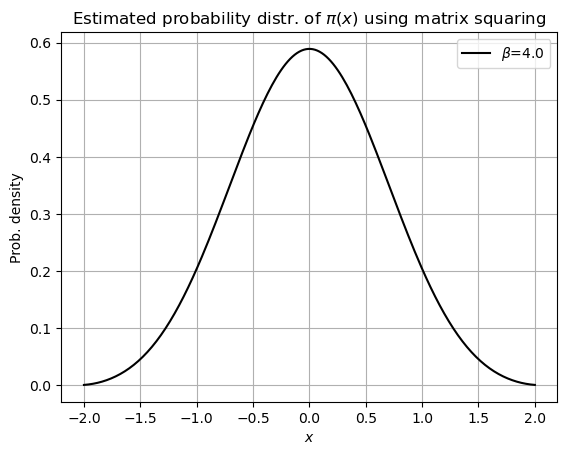

In [16]:
# Define initial and final values for beta
beta_final = 4.0
beta = 1 / (2 ** 6)

# Define xrange and calculate the potential
xrange = np.linspace(-2, 2, 200)
potential = 0.5 * np.square(xrange)

# Apply matrix squaring
rho = matrix_squaring(xrange, potential, beta, beta_final)

pi = prob_distr(xrange, rho)
fn = 'data_harm_matrixsquaring_beta' + str(beta)

plt.plot(xrange, pi, color='black', label=rf'$\beta$={beta_final}')
plt.xlabel(r"$x$")
plt.ylabel('Prob. density')
plt.grid()
plt.legend()
plt.title(rf"Estimated probability distr. of $\pi(x)$ using matrix squaring")
plt.savefig(f"plots/matrix_squaring_beta_{beta:.1f}.png")
plt.show()

### B2: *Path Integral*

In [17]:
# Re-difinition
@njit
def scalar_free_density_matrix(x: float, xp: float, beta: float) -> float:
    '''Scalar computation of free density matrix.'''
    return np.exp(-(x - xp) ** 2 / (2 * beta)) / np.sqrt(np.pi)

In [18]:
@njit
def naive_harmonic_path(x: np.ndarray, # (N, )
                        beta: float,
                        delta: float = 0.05,
                       ) -> np.ndarray:
    N = x.shape[0]
    Delta_t = beta / N
    k = np.random.randint(0, N)
    prv = (k - 1) % N
    nxt = (k + 1) % N
    dx = np.random.uniform(-delta, delta)
    pi_a = scalar_free_density_matrix(x[prv], x[k], Delta_t) \
         * scalar_free_density_matrix(x[k], x[nxt], Delta_t) \
         * np.exp(-0.5 * Delta_t * x[k] ** 2)
    pi_b = scalar_free_density_matrix(x[prv], x[k] + dx, Delta_t) \
         * scalar_free_density_matrix(x[k] + dx, x[nxt], Delta_t) \
         * np.exp(-0.5 * Delta_t * (x[k] + dx) ** 2)
    Upsilon = pi_b / pi_a
    if np.random.rand() < Upsilon:
        x[k] += dx
    return x

In [19]:
@njit
def harmonic_path_integral_sampling(N: int = 10,
                                    beta: float = 0.4,
                                    n_steps: int = 1000000,
                                    index: int = 0,
                                    delta: float = 0.05,
                                   ) -> np.ndarray:
    x = np.zeros(N, dtype=np.float64)
    results = List()
    for step in range(n_steps):
        x = naive_harmonic_path(x, beta=beta, delta=delta)
        if step % 10 == 0:
            results.append(x[0])
    return results

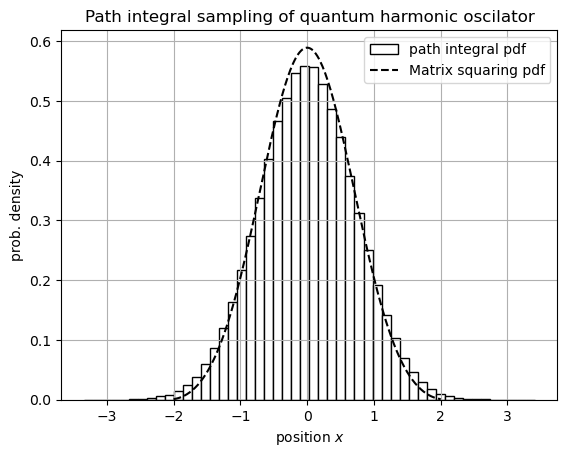

In [20]:
results = harmonic_path_integral_sampling(
    N=10, 
    beta=4.0,
    index=0,
    n_steps=10_000_000,
    delta=0.5
)
plt.hist(results, bins=50, color='white', edgecolor='black', density=True, label='path integral pdf')
plt.plot(xrange, pi, '--', color='black', label='Matrix squaring pdf')
plt.xlabel(r'position $x$')
plt.ylabel('prob. density')
plt.title('Path integral sampling of quantum harmonic oscilator')
plt.legend()
plt.grid()
plt.savefig('plots/path_integral.png')
plt.show()

## Section C: *The anharmonic potential*

$$V(x) = x^2 - q x^3 + q x ^ 4$$

With $q > 0$

### C1: *Matrix Squaring*

In [21]:
@njit
def V(x, q=0):
    return 0.5 * x ** 2 - q * x ** 3 + q * x ** 4

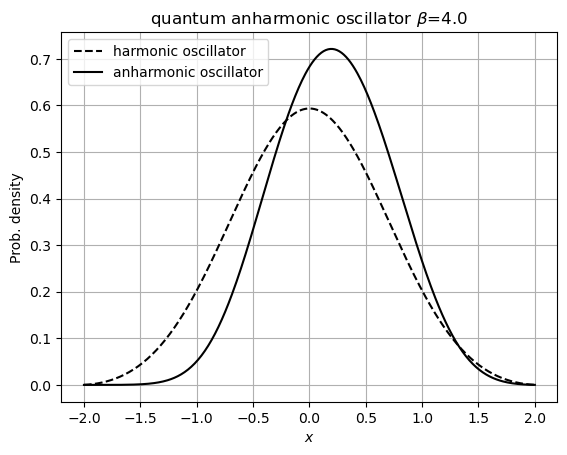

In [22]:
# Define initial and final values for beta
beta_final = 4.0
beta = 1 / (2 ** 8)

# Define xrange and calculate the potential
xrange = np.linspace(-2, 2, 400)
pot_h = V(xrange, q=0.0)
pot_ah = V(xrange, q=1.0)


rho_h = matrix_squaring(xrange, pot_h, beta, beta_final)
rho_ah = matrix_squaring(xrange, pot_ah, beta, beta_final)

pi_h = prob_distr(xrange, rho_h)
pi_ah = prob_distr(xrange, rho_ah)

plt.plot(xrange, pi_h, '--', color='black', label='harmonic oscillator')
plt.plot(xrange, pi_ah, color='black', label='anharmonic oscillator')
plt.xlabel(r"$x$")
plt.ylabel('Prob. density')
plt.grid()
plt.legend()
plt.title(rf"quantum anharmonic oscillator $\beta$={beta_final:.1f}")
plt.savefig(f"plots/nh_matrix_squaring_beta_{beta:.1f}.png")
plt.show()

### C2: *Path integral*

In [23]:
@njit
def naive_anharmonic_path(x: np.ndarray, # (N, )
                          beta: float,
                          delta: float = 0.05,
                          q: float = 0.0,
                         ) -> np.ndarray:
    N = x.shape[0]
    Delta_t = beta / N
    k = np.random.randint(0, N)
    prv = (k - 1) % N
    nxt = (k + 1) % N
    dx = np.random.uniform(-delta, delta)
    pi_a = scalar_free_density_matrix(x[nxt], x[k], Delta_t) \
         * scalar_free_density_matrix(x[k], x[prv], Delta_t) \
         * np.exp(-0.5 * Delta_t * V(x[k], q))
    pi_b = scalar_free_density_matrix(x[nxt], x[k] + dx, Delta_t) \
         * scalar_free_density_matrix(x[k] + dx, x[prv], Delta_t) \
         * np.exp(-0.5 * Delta_t * V(x[k] + dx, q))
    Upsilon = pi_b / pi_a
    if np.random.rand() < Upsilon:
        x[k] += dx
    return x

In [24]:
@njit
def anharmonic_path_integral_sampling(N: int = 10,
                                      beta: float = 0.4,
                                      n_steps: int = 1000000,
                                      delta: float = 0.05,
                                      q: float = 0.0) -> np.ndarray:
    x = np.zeros(N, dtype=np.float64)
    results = List()
    for step in range(n_steps):
        x = naive_anharmonic_path(x, beta=beta, delta=delta, q=q)
        if step % 10 == 0:
            results.append(x[0])
    return results

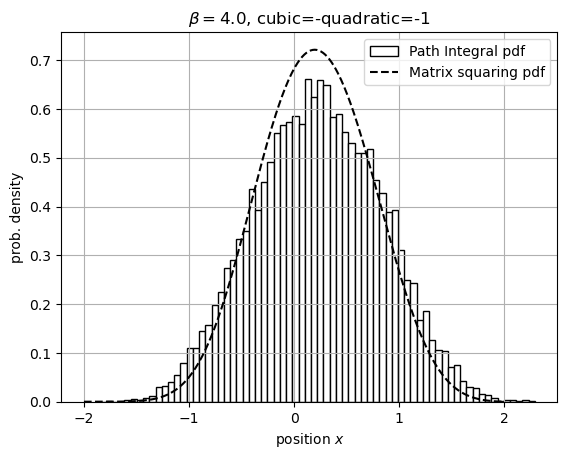

In [25]:
results = anharmonic_path_integral_sampling(
    N=16,
    beta=4.0,
    n_steps=1_000_000,
    delta=1.0, 
    q=1.0
)

plt.hist(results, bins=70, color='white', edgecolor='black', density=True, label='Path Integral pdf')
plt.plot(xrange, pi_ah, '--', color='black', label='Matrix squaring pdf')
plt.xlabel(r'position $x$')
plt.ylabel('prob. density')
plt.title(r'$\beta=4.0$, cubic=-quadratic=-1')
plt.legend()
plt.grid()
plt.savefig('plots/ah_path_integral.png')
plt.show()

### C3: *Petrubaitive solution*

When the cubic and quartic parameters are rather small, the anharmonic  potential is similar to the harmonic one. In this case, there exists a  perturbative  expression for the energy levels $E_n(q)$ of the anharmonic oscillator. This expression (that is too complicated for us to derive) allows us to compute the partition function 
$$Z = \sum_n \exp{(-\beta E_n)}$$ for small cubic and quartic (this is the 
meaning of the word "perturbative"), but it becomes totally wrong at 
larger values of the parameters.

Here is the code snippet which does 

In [26]:
import math 

def Energy_pert(n, quartic):
    cubic = -quartic
    return n + 0.5 - 15.0 / 4.0 * cubic **2 * (n ** 2 + n + 11.0 / 30.0) \
         + 3.0 / 2.0 * quartic * (n ** 2 + n + 1.0 / 2.0)

def Z_pert(quartic, beta, n_max):
    Z = sum(math.exp(-beta * Energy_pert(n, quartic)) for n in range(n_max + 1))
    return Z

In [27]:
beta, beta_final = 2 ** (-8), 2.0
qs = [0.001,0.01,0.1,0.2,0.3,0.4,0.5]
Z_petr_values = []
Z_mat_sqr_values = []

for q in qs:
    Z_petr_values.append(Z_pert(q, beta_final, 20))
    rho = matrix_squaring(xrange, V(xrange, q=q), beta, beta_final)
    Z = partition_function(xrange, rho)
    Z_mat_sqr_values.append(Z)

print('quartic', 'Z comp', 'Z petr', sep='\t')
for q, zc, zp in zip(qs, Z_mat_sqr_values, Z_petr_values):
    print(f'{q:.3f}', f'{zc:.3f}', f'{zp:.3f}', sep='\t')

quartic	Z comp	Z petr
0.001	0.377	0.424
0.010	0.373	0.415
0.100	0.344	0.355
0.200	0.320	0.328
0.300	0.303	0.328
0.400	0.289	0.363
0.500	0.278	369968474007694509558864833783030076884025249628160.000


NB: The perturbation-theoretical calculation is performed in Landau Lifshitz: "Quantum Mechanics (vol 3)", exercise 3 of 
chap 38. You do not have to look this reference up.

NNB: Note that you are actually using and checking the marvelous formula:  $$Z = \sum_n \exp(-\beta E_n) = \int dx \rho(x,x, \beta)$$